In [25]:
import logging

logging.basicConfig(level=logging.INFO)

# Import the modules to extract hierarchical area data and plot the results
from area import extract_areas, get_path

from plot import PULP_COLORS_BASE, smooth_polygon

# Argparse is a module that allows you to parse command-line arguments
# See https://docs.python.org/3/library/argparse.html for more information
import argparse

# Import the matplotlib library for plotting
# See https://matplotlib.org/stable/gallery/index.html for examples
from matplotlib import pyplot as plt
import matplotlib.patches as patches

# Import the os module to create directories
import os



In [26]:
# IHP-130 sg13g2_stdcell library (1 GE = 7.25 um^2)
# See http://eda.ee.ethz.ch/index.php?title=Ihp13#What_is_one_gate_equivalent_?
AREA_PER_GE = 7.25

FILE = './croc.area.rpt'

In [27]:

# Extract the hierarchical area data
area_tree = extract_areas(FILE)

if area_tree is None:
    raise ValueError("No hierarchical area data found.")

print(area_tree)

INFO:root:Reading area report from ./croc.area.rpt


<top> (3018194.922 um^2)


In [28]:

# Extract the hierarchical area data
node_i_croc = get_path(area_tree, ["<top>", "i_croc_soc", "i_croc"])

# Extract names and convert areas to kGE
names = []
areas_kge = []

for node in node_i_croc.children:
    # print(node)
    # Convert area from um^2 to kGE
    area_kge = node.area / (AREA_PER_GE * 1e3)
    areas_kge.append(area_kge)
    names.append(node.name)

    # print(area_kge)

node_i_user_block_swap_config = get_path(area_tree, ["<top>", "i_croc_soc", "i_user.i_block_swap_ctrl"])
if node_i_user_block_swap_config is None:
    raise ValueError("No 'i_user.i_block_swap_ctrl' node found in the area tree.")
# print(node_i_user_block_swap_config)
area_kge = node_i_user_block_swap_config.area / (AREA_PER_GE * 1e3)
areas_kge.append(area_kge)
names.append(node_i_user_block_swap_config.name)
# print(area_kge)

node_i_user_rom = get_path(area_tree, ["<top>", "i_croc_soc", "i_user.i_user_rom"])
if node_i_user_rom is None:
    raise ValueError("No 'i_user.i_user_rom' node found in the area tree.")
# print(node)
area_kge = node_i_user_rom.area / (AREA_PER_GE * 1e3)
areas_kge.append(area_kge)
names.append(node_i_user_rom.name)
# print(area_kge)

node_i_user_transparentspi = get_path(area_tree, ["<top>", "i_croc_soc", "i_user.i_block_swap_ctrl"])
if node_i_user_transparentspi is None:
    raise ValueError("No 'i_user.i_block_swap_ctrl' node found in the area tree.")
# print(node)
area_kge = node_i_user_transparentspi.area / (AREA_PER_GE * 1e3)
areas_kge.append(area_kge)
names.append(node_i_user_transparentspi.name)
# print(area_kge)

node_i_user_transparentspi = get_path(area_tree, ["<top>", "i_croc_soc", "i_user.i_req_blocker_ctrl"])
if node_i_user_transparentspi is None:
    raise ValueError("No 'i_user.i_req_blocker_ctrl' node found in the area tree.")
# print(node)
area_kge = node_i_user_transparentspi.area / (AREA_PER_GE * 1e3)
areas_kge.append(area_kge)
names.append(node_i_user_transparentspi.name)
# print(area_kge)

node_i_user_transparentspi = get_path(area_tree, ["<top>", "i_croc_soc", "i_user.i_user_transparentspi"])
if node_i_user_transparentspi is None:
    raise ValueError("No 'i_user.i_user_transparentspi' node found in the area tree.")
# print(node)
area_kge = node_i_user_transparentspi.area / (AREA_PER_GE * 1e3)
areas_kge.append(area_kge)
names.append(node_i_user_transparentspi.name)
# print(area_kge)

print(names)
# print(areas_kge)

['gen_sram_bank\\[0\\].i_sram', 'gen_sram_bank\\[1\\].i_sram', 'gen_sram_bank\\[2\\].i_sram', 'gen_sram_bank\\[3\\].i_sram', 'i_bootrom', 'i_core_data_req_blocker', 'i_core_instr_req_blocker', 'i_core_wrap', 'i_dm_top.i_dm_top', 'i_dmi_jtag', 'i_gpio', 'i_periph_obi_cut', 'i_soc_ctrl', 'i_timer', 'i_uart', 'i_user_obi_cut', 'i_user.i_block_swap_ctrl', 'i_user.i_user_rom', 'i_user.i_block_swap_ctrl', 'i_user.i_req_blocker_ctrl', 'i_user.i_user_transparentspi']


In [29]:
from flask import request


names = [
    "SRAM Bank 1",
    "SRAM Bank 2",
    "SRAM Bank 3",
    "SRAM Bank 4",
    "Bootrom",
    "Data Request Blocker",
    "Instruction Request Blocker",
    "Core",
    "Debug Module",
    "JTAG TAP",
    "GPIO",
    "Peripheral OBI Cut",
    "SoC Control",
    "Timer",
    "UART",
    "User OBI Cut",
    "Block Swap Config",
    "User ROM",
    "Block Swap Control",
    "Request Blocker Control",
    "Transparent SPI",
]

colors = [PULP_COLORS_BASE[i % len(PULP_COLORS_BASE)] for i in range(len(names))]

# Normalize values for bar lengths
total_area = sum(areas_kge)
norm_values = [a / total_area for a in areas_kge]
left_positions = [sum(norm_values[:i]) for i in range(len(norm_values))]

# Split components into two groups
first_row_names = ["Core", "UART"]
second_row_names = ["Debug Module", "JTAG TAP", "GPIO", "SoC Control", "Timer"]
this_project_names = ["Peripheral OBI Cut", "User OBI Cut", "Block Swap Config", "Transparent SPI", "Block Swap Control", "Request Blocker Control"]
request_blockers = ["Data Request Blocker", "Instruction Request Blocker"]
rom_names = ["Bootrom", "User ROM"]
sram_names = ["SRAM Bank 1", "SRAM Bank 2", "SRAM Bank 3", "SRAM Bank 4"]

# Compute values
sram_area = sum(areas_kge[names.index(n)] for n in sram_names)
roms_area = sum(areas_kge[names.index(n)] for n in rom_names)
request_blockers_area = sum(areas_kge[names.index(n)] for n in request_blockers)
project_area = sum(areas_kge[names.index(n)] for n in this_project_names) + roms_area + request_blockers_area
rest_area = sum(areas_kge[names.index(n)] for n in second_row_names) + project_area

first_row = {
    n: {"area": areas_kge[names.index(n)], "color": colors[names.index(n)]}
    for n in first_row_names
}
first_row["Rest"] = {"area": rest_area, "color": PULP_COLORS_BASE[-1]}
first_row["SRAM Banks"] = {"area": sram_area, "color": PULP_COLORS_BASE[0]}

second_row = {
    n: {"area": areas_kge[names.index(n)], "color": colors[names.index(n)]}
    for n in second_row_names
}
second_row["This Project"] = {"area": project_area, "color": PULP_COLORS_BASE[-1]}

third_row = {
    n: {"area": areas_kge[names.index(n)], "color": colors[names.index(n)]}
    for n in this_project_names
}
third_row["ROMs"] = {
    "area": roms_area,
    "color": PULP_COLORS_BASE[-1],
}
third_row["Request Blockers"] = {
    "area": request_blockers_area,
    "color": PULP_COLORS_BASE[5],
}

# fourth_row = {
#     n: {"area": areas_kge[names.index(n)], "color": colors[names.index(n)]}
#     for n in rom_names
# }

# Sort rows by area
first_row = dict(
    sorted(first_row.items(), key=lambda x: x[1]["area"], reverse=True)
)
second_row = dict(
    sorted(second_row.items(), key=lambda x: x[1]["area"], reverse=True)
)
third_row = dict(
    sorted(third_row.items(), key=lambda x: x[1]["area"], reverse=True)
)
# fourth_row = dict(
#     sorted(fourth_row.items(), key=lambda x: x[1]["area"], reverse=True)
# )

In [30]:
# Helper to plot a row
def plot_row(y, row_dict, total_area, exact=False):
    """
    Plot a horizontal stacked bar at vertical position y from the given area dictionary.

    Args:
        y (float): Vertical position of the bar (row) in the plot.
        row_dict (dict): Dictionary mapping component names to their area and color,
                         e.g. {'UART': {'area': 10.5, 'color': '#ff0000'}}.
        total_area (float): Total area of all components (used to calculate global percentages).
        exact (bool): If True, display as GE instead of kGE and percentages to two decimal places.

    Returns:
        tuple: A tuple containing:
            - labels (list[str]): List of component names in the row.
            - norm_row (list[float]): Normalized area values for the row (sum to 1).
            - left (list[float]): Left positions for each bar segment in the row.
    """
    labels, areas, colors = zip(
        *[(k, v["area"], v["color"]) for k, v in row_dict.items()]
    )
    row_total = sum(areas)
    norm_row = [a / row_total for a in areas]
    norm_total = [a / total_area for a in areas]
    left = [sum(norm_row[:i]) for i in range(len(norm_row))]

    x = 0
    for label, val, frac_row, color, frac_total in zip(
        labels, areas, norm_row, colors, norm_total
    ):
        ax.barh(
            y,
            frac_row,
            left=x,
            height=BAR_HEIGHT,
            color=color,
            edgecolor="white",
            linewidth=2,
        )
        ax.text(
            x + frac_row / 2,
            y - POS1 * BAR_HEIGHT,
            label,
            ha="left",
            va="bottom",
            fontsize=10,
            rotation=45,
            # weight="bold",
        )
        ax.text(
            x + frac_row / 2,
            y + POS1 * BAR_HEIGHT + (0.02 if val < 0.5 else 0),
            f"{val:.1f}" if not exact else f"{val * 1000:.0f}",
            ha="center",
            va="center",
            fontsize=10,
            weight="bold",
            rotation=45 if val < 0.5 else 0,
        )
        ax.text(
            x + frac_row / 2,
            y + POS2 * BAR_HEIGHT + (0.05 if frac_total < 0.005 else 0),
            f"{frac_total:.1%}" if not exact else f"{frac_total:.2%}",
            ha="center",
            va="center",
            fontsize=10,
            rotation=45 if frac_total < 0.005 else 0,
        )
        x += frac_row

    ax.text(
        1.02,
        y,
        f"{row_total:.0f}" if not exact else f"{row_total * 1000:.0f}",
        ha="left",
        va="center",
        fontsize=10,
        weight="bold",
    )
    ax.text(
        1.02,
        y + POS1 * BAR_HEIGHT,
        "kGE" if not exact else "GE",
        ha="left",
        va="center",
        fontsize=10,
        weight="bold",
    )
    ax.text(
        1.02,
        y + POS2 * BAR_HEIGHT,
        "%",
        ha="left",
        va="center",
        fontsize=10,
        weight="bold",
    )

    return labels, norm_row, left

In [31]:
BAR_HEIGHT = 0.3
Y_OFFSET = 1.0
POS1 = 0.6
POS2 = 0.8

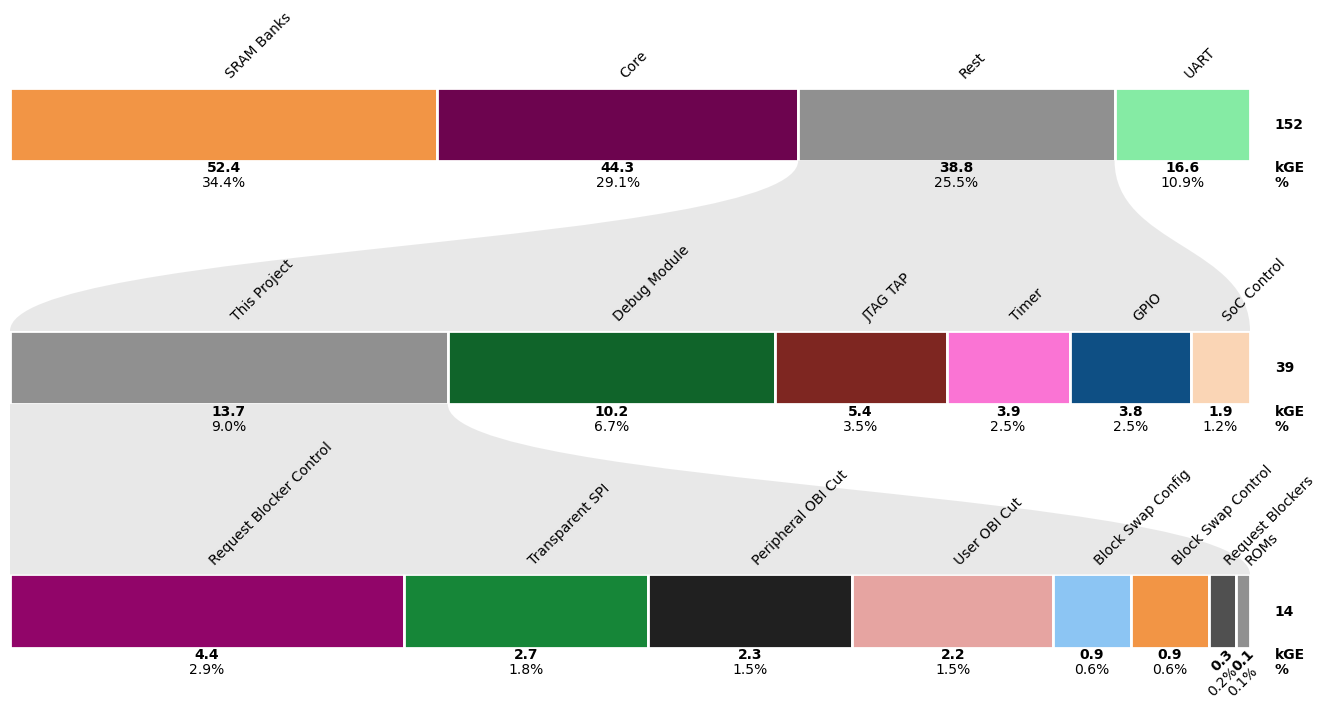

In [32]:
# Plot setup
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.axis("off")

# Draw both rows
labels1, norm_row1, left1 = plot_row(0, first_row, total_area)
labels2, norm_row2, left2 = plot_row(Y_OFFSET, second_row, total_area)
labels3, norm_row3, left3 = plot_row(Y_OFFSET * 2, third_row, total_area)
# labels4, norm_row4, left4 = plot_row(Y_OFFSET * 3, fourth_row, total_area, exact=True)

# Connect "Rest" to second row
rest_index = labels1.index("Rest")
this_project_index = labels2.index("This Project")
# roms_index = labels3.index("ROMs")

p1 = (left1[rest_index], BAR_HEIGHT / 2)
p2 = (left1[rest_index] + norm_row1[rest_index], BAR_HEIGHT / 2)
p3 = (sum(norm_row2), Y_OFFSET - BAR_HEIGHT / 2)
p4 = (0, Y_OFFSET - BAR_HEIGHT / 2)

polygon = smooth_polygon(p1, p2, p3, p4)
patch = patches.PathPatch(polygon, color=PULP_COLORS_BASE[-1], alpha=0.2, lw=0)
ax.add_patch(patch)

p1 = (left2[this_project_index], BAR_HEIGHT / 2 + Y_OFFSET)
p2 = (left2[this_project_index] + norm_row2[this_project_index], BAR_HEIGHT / 2 + Y_OFFSET)
p3 = (sum(norm_row3), Y_OFFSET * 2 - BAR_HEIGHT / 2)
p4 = (0, Y_OFFSET * 2 - BAR_HEIGHT / 2)

polygon = smooth_polygon(p1, p2, p3, p4)
patch = patches.PathPatch(polygon, color=PULP_COLORS_BASE[-1], alpha=0.2, lw=0)
ax.add_patch(patch)

# p1 = (left3[roms_index], BAR_HEIGHT / 2 + Y_OFFSET * 2)
# p2 = (left3[roms_index] + norm_row3[roms_index], BAR_HEIGHT / 2 + Y_OFFSET * 2)
# p3 = (sum(norm_row4), Y_OFFSET * 3 - BAR_HEIGHT / 2)
# p4 = (0, Y_OFFSET * 3 - BAR_HEIGHT / 2)
# polygon = smooth_polygon(p1, p2, p3, p4)
# patch = patches.PathPatch(polygon, color=PULP_COLORS_BASE[-1], alpha=0.2, lw=0)
# ax.add_patch(patch)

# Create a directory if it does not exist
os.makedirs("plots", exist_ok=True)

# Save figure
plt.savefig("plots/area_breakdown.pdf", bbox_inches='tight')
plt.savefig("plots/area_breakdown.png", bbox_inches='tight')

# Display the plot
plt.show()